<a href="https://colab.research.google.com/github/jasonnho/flygaruda-sentiment-analysis/blob/main/Tugas%202/Tugas_2_Performance_Analisis_Sentimen_with_Transformer_PBA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jason Ho - 5026221005
# Tugas 2 Performance Analisis Sentimen with Transformer - PBA A

# Install Depedency

In [2]:
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn matplotlib --quiet


# Import Library

In [3]:
import os
import math
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Load Dataset

In [4]:
DATA_PATH = "/content/7-garudaindonesia_news_cleaned_simple.csv"

df = pd.read_csv(DATA_PATH)
print("Kolom yang tersedia:", df.columns.tolist())
print("Jumlah baris:", len(df))
df.head()


Kolom yang tersedia: ['link', 'judul', 'konten', 'tanggal', 'portal', 'tag', 'konten_hapus_karakter', 'konten_normalized', 'konten_nostop', 'konten_stem', 'konten_stem_clean', 'sentiment', 'tag_new']
Jumlah baris: 469


,link,judul,konten,tanggal,portal,tag,konten_hapus_karakter,konten_normalized,konten_nostop,konten_stem,konten_stem_clean,sentiment,tag_new
0,https://kumparan.com/kumparanbisnis/garuda-ind...,Garuda Indonesia Kembali RUPSLB di Tengah Isu ...,Garuda Indonesia Kembali RUPSLB di Tengah Isu ...,30/09/2025,Kumparan,Manajemen,garuda indonesia kembali rupslb di tengah isu ...,garuda indonesia kembali rupslb di tengah isu ...,garuda indonesia rupslb tengah isu petinggi si...,garuda indonesia rupslb tengah isu petinggi si...,garuda indonesia rupslb tengah isu petinggi si...,Neutral,Kinerja & Keuangan
1,https://www.bloombergtechnoz.com/detail-news/8...,Garuda Gelar RUPSLB di Tengah Isu Masuknya Dir...,Garuda Gelar RUPSLB di Tengah Isu Masuknya Dir...,29/09/2025,Bloomberg Technoz,Manajemen,garuda gelar rupslb di tengah isu masuknya dir...,garuda gelar rupslb di tengah isu masuknya dir...,garuda gelar rupslb tengah isu masuknya direks...,garuda gelar rupslb tengah isu masuk direksi a...,garuda gelar rupslb tengah isu masuk direksi a...,Neutral,Regulasi & Kebijakan
2,https://voi.id/ekonomi/519004/komisi-v-dpr-bak...,Komisi V DPR Bakal Dalami Dugaan Mafia Jual Be...,JAKARTA - Ketua Komisi V DPR Lasarus mengataka...,29/09/2025,VOI.ID,Rute/Operasional,jakarta ketua komisi v dpr lasarus mengatakan ...,jakarta ketua komisi v dpr lasarus mengatakan ...,jakarta ketua komisi v dpr lasarus mengatakan ...,jakarta ketua komisi v dpr lasarus kata dalam ...,jakarta ketua komisi v dpr lasarus kata dalam ...,Negative,Krisis & Kontroversi
3,https://www.kompasiana.com/zainularifin2714/68...,Rencana Merger Garuda Indonesia - Pelita Air: ...,"Latar Belakang\nPada pertengahan 2023, wacana ...",29/09/2025,Kompasiana.com,Lainnya,latar belakang pada pertengahan wacana konsoli...,latar belakang pada pertengahan wacana konsoli...,latar belakang pertengahan wacana konsolidasi ...,latar belakang tengah wacana konsolidasi maska...,latar belakang tengah wacana konsolidasi maska...,Neutral,Kinerja & Keuangan
4,https://www.cnnindonesia.com/ekonomi/202509292...,Dony Oskaria Pastikan Merger Pelita Air-Garuda...,--\nPlt Menteri Badan Usaha Milik Negara (BUMN...,29/09/2025,CNN Indonesia,Lainnya,plt menteri badan usaha milik negara bumn seka...,plt menteri badan usaha milik negara bumn seka...,plt menteri badan usaha milik negara bumn seka...,plt menteri badan usaha milik negara bumn seka...,plt menteri badan usaha milik negara bumn seka...,Neutral,Operasional & Pelayanan


# Select Column
Akan digunakan 2 kolom untuk percobaan, pertama konten asli yang telah di lowercase dan normalisasi dan kolom kedua yaitu kolom yang sudah di clean

In [5]:
RAW_TEXT_COL   = "konten_normalized"
CLEAN_TEXT_COL = "konten_stem_clean"
LABEL_COLUMN   = "sentiment"

df_clf = df[[RAW_TEXT_COL, CLEAN_TEXT_COL, LABEL_COLUMN]].dropna(subset=[LABEL_COLUMN])
print(df_clf.head())
print("Jumlah data setelah drop NA:", len(df_clf))
print(df_clf[LABEL_COLUMN].value_counts())


                                   konten_normalized  \
0  garuda indonesia kembali rupslb di tengah isu ...   
1  garuda gelar rupslb di tengah isu masuknya dir...   
2  jakarta ketua komisi v dpr lasarus mengatakan ...   
3  latar belakang pada pertengahan wacana konsoli...   
4  plt menteri badan usaha milik negara bumn seka...   

                                   konten_stem_clean sentiment  
0  garuda indonesia rupslb tengah isu petinggi si...   Neutral  
1  garuda gelar rupslb tengah isu masuk direksi a...   Neutral  
2  jakarta ketua komisi v dpr lasarus kata dalam ...  Negative  
3  latar belakang tengah wacana konsolidasi maska...   Neutral  
4  plt menteri badan usaha milik negara bumn seka...   Neutral  
Jumlah data setelah drop NA: 469
sentiment
Positive    201
Negative    183
Neutral      85
Name: count, dtype: int64


# Encode Label
Label sentiment di encode menjadi angka 0/1/2 agar bisa digunakan PyTorch

In [6]:
unique_labels = sorted(df_clf[LABEL_COLUMN].unique())
print("Unique labels:", unique_labels)

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id:", label2id)

df_clf["label_id"] = df_clf[LABEL_COLUMN].map(label2id)

print(df_clf[["sentiment", "label_id"]].head())
print(df_clf["label_id"].value_counts())


Unique labels: ['Negative', 'Neutral', 'Positive']
label2id: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
  sentiment  label_id
0   Neutral         1
1   Neutral         1
2  Negative         0
3   Neutral         1
4   Neutral         1
label_id
2    201
0    183
1     85
Name: count, dtype: int64


# Fungsi get_splits() supaya bisa dipakai untuk 2 kolom teks

In [47]:
from sklearn.model_selection import train_test_split

def get_splits(text_column_name, df_source=None, label_col="label_id",
               test_size=0.3, val_size=0.5, random_state=42):

    if df_source is None:
        df_source = df_clf

    texts = df_source[text_column_name].astype(str).tolist()
    labels = df_source[label_col].tolist()

    # Train vs (Val+Test)
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        texts,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels
    )

    # Bagi (Val+Test) jadi Val & Test
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts,
        temp_labels,
        test_size=val_size,  # misal 0.5 → val 15%, test 15%
        random_state=random_state,
        stratify=temp_labels
    )

    splits = {
        "train_texts": train_texts,
        "val_texts": val_texts,
        "test_texts": test_texts,
        "train_labels": train_labels,
        "val_labels": val_labels,
        "test_labels": test_labels,
    }
    return splits


Split raw text

In [8]:
splits_raw = get_splits(RAW_TEXT_COL)

for k, v in splits_raw.items():
    print(k, ":", len(v))


train_texts : 328
val_texts : 70
test_texts : 71
train_labels : 328
val_labels : 70
test_labels : 71


Split Cleaned Text

In [9]:
splits_clean = get_splits(CLEAN_TEXT_COL)
for k, v in splits_clean.items():
    print(k, ":", len(v))

train_texts : 328
val_texts : 70
test_texts : 71
train_labels : 328
val_labels : 70
test_labels : 71


# Build Vocabulary

In [10]:
train_texts = splits_raw["train_texts"]
val_texts   = splits_raw["val_texts"]
test_texts  = splits_raw["test_texts"]

train_labels = splits_raw["train_labels"]
val_labels   = splits_raw["val_labels"]
test_labels  = splits_raw["test_labels"]

len(train_texts), len(val_texts), len(test_texts)


(328, 70, 71)

In [11]:
#Tokenizer
def tokenize(text):
    return str(text).split()

# Kumpulkan semua token di train
all_tokens = []
for t in train_texts:
    all_tokens.extend(tokenize(t))

token_freq = Counter(all_tokens)
print("Jumlah token unik di train:", len(token_freq))

# Bikin vocab dengan minimum frequency
MIN_FREQ = 2

vocab = {"[PAD]": 0, "[UNK]": 1}
for tok, freq in token_freq.items():
    if freq >= MIN_FREQ and tok not in vocab:
        vocab[tok] = len(vocab)

vocab_size = len(vocab)
print("Ukuran vocab:", vocab_size)

pad_idx = vocab["[PAD]"]
unk_idx = vocab["[UNK]"]


Jumlah token unik di train: 7239
Ukuran vocab: 4543


In [12]:
# Hitung max_len dari 95 percentile
lengths = [len(tokenize(t)) for t in train_texts]
max_len = int(np.percentile(lengths, 95))
print("Max len (p95):", max_len)


Max len (p95): 629


# Encode Text

In [13]:
# Encode text -> ids + attention mask

def encode_text(text, vocab, max_len, pad_idx=0, unk_idx=1):
    tokens = tokenize(text)
    ids = [vocab.get(tok, unk_idx) for tok in tokens]

    # truncate kalau kepanjangan
    if len(ids) > max_len:
        ids = ids[:max_len]

    # attention mask: 1 untuk token asli, 0 untuk padding
    attn_mask = [1] * len(ids)

    # padding sampai max_len
    while len(ids) < max_len:
        ids.append(pad_idx)
        attn_mask.append(0)

    return ids, attn_mask


In [14]:
sample_text = train_texts[0]
ids, mask = encode_text(sample_text, vocab, max_len, pad_idx=pad_idx, unk_idx=unk_idx)
print("Contoh teks:", sample_text[:100], "...")
print("Panjang ids:", len(ids))
print("Panjang mask:", len(mask))
print("5 token pertama:", ids[:5])
print("5 mask pertama:", mask[:5])


Contoh teks: jam terbang bertambah garuda indonesia bakal beli unit pesawat akhir maskapai garuda indonesia akan  ...
Panjang ids: 629
Panjang mask: 629
5 token pertama: [2, 3, 4, 5, 6]
5 mask pertama: [1, 1, 1, 1, 1]


In [15]:
# Dataset untuk berita Garuda Indonesia
class NewsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len, pad_idx=0, unk_idx=1):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.unk_idx = unk_idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids, attn_mask = encode_text(
            text,
            self.vocab,
            self.max_len,
            pad_idx=self.pad_idx,
            unk_idx=self.unk_idx
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn_mask, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }


In [16]:
# Buat dataset untuk splits_raw

train_dataset = NewsDataset(train_texts, train_labels, vocab, max_len, pad_idx, unk_idx)
val_dataset   = NewsDataset(val_texts,   val_labels,   vocab, max_len, pad_idx, unk_idx)
test_dataset  = NewsDataset(test_texts,  test_labels,  vocab, max_len, pad_idx, unk_idx)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Cek satu batch
batch = next(iter(train_loader))
print(batch["input_ids"].shape)       # harusnya (batch_size, max_len)
print(batch["attention_mask"].shape)  # sama
print(batch["labels"].shape)          # (batch_size,)


torch.Size([32, 629])
torch.Size([32, 629])
torch.Size([32])


# Build Transformer

In [17]:
# Positional Encoding (sinusoidal)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


In [18]:
# Model Transformer untuk klasifikasi sentimen

class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_heads=4,
        num_layers=2,
        ff_dim=256,
        num_classes=3,
        dropout=0.1,
        pad_idx=0,
        max_len=512,
    ):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=False,  # input ke encoder: (seq, batch, dim)
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.pad_idx = pad_idx

    def forward(self, input_ids, attention_mask=None):
        # input_ids: (batch, seq_len)
        x = self.embed(input_ids)          # (batch, seq_len, embed_dim)
        x = self.pos_encoder(x)           # (batch, seq_len, embed_dim)
        x = x.transpose(0, 1)             # (seq_len, batch, embed_dim)

        # key_padding_mask: True di posisi PAD
        if attention_mask is not None:
            key_padding_mask = (attention_mask == 0)  # (batch, seq_len)
        else:
            key_padding_mask = None

        encoded = self.transformer_encoder(
            x,
            src_key_padding_mask=key_padding_mask
        )                                  # (seq_len, batch, embed_dim)

        encoded = encoded.transpose(0, 1)  # (batch, seq_len, embed_dim)

        # Mean pooling hanya di token non-pad
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)  # (batch, seq_len, 1)
            summed = (encoded * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1)
            pooled = summed / counts
        else:
            pooled = encoded.mean(dim=1)

        logits = self.classifier(self.dropout(pooled))  # (batch, num_classes)
        return logits


In [19]:
# Inisialisasi model + config baseline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

NUM_CLASSES = len(label2id)

model = TransformerClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=256,
    num_classes=NUM_CLASSES,
    dropout=0.1,
    pad_idx=pad_idx,
    max_len=max_len,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [20]:
# Tes satu batch lewat model

batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)

with torch.no_grad():
    logits = model(input_ids, attention_mask)

print("Logits shape:", logits.shape)  # harusnya (batch_size, NUM_CLASSES)


Logits shape: torch.Size([32, 3])


# Helper Evaluasi

In [21]:
from sklearn.metrics import precision_recall_fscore_support

# Evaluasi acc, precision, recall, f1

def evaluate_full(model, data_loader, criterion, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average='macro',  # macro = rata-rata antar kelas (fair untuk imbalanced)
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# Baseline Epoch = 10

In [22]:
# Training loop baseline (10 epoch)

NUM_EPOCHS = 10  # sesuai instruksi tugas utk model awal

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # hitung metrik train
    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(all_labels, all_preds)

    val_metrics = evaluate_full(model, val_loader, criterion, DEVICE)

    val_loss = val_metrics["loss"]
    val_acc = val_metrics["acc"]
    val_prec = val_metrics["precision"]
    val_rec  = val_metrics["recall"]
    val_f1   = val_metrics["f1"]

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
        f"Val P: {val_prec:.4f} | Val R: {val_rec:.4f} | Val F1: {val_f1:.4f}"
    )


Epoch 01 | Train Loss: 1.0651 | Val Loss: 1.0434 | Train Acc: 0.3963 | Val Acc: 0.4286 | Val P: 0.2857 | Val R: 0.3370 | Val F1: 0.2524
Epoch 02 | Train Loss: 1.0369 | Val Loss: 1.0412 | Train Acc: 0.4421 | Val Acc: 0.4286 | Val P: 0.1429 | Val R: 0.3333 | Val F1: 0.2000
Epoch 03 | Train Loss: 1.0286 | Val Loss: 1.0244 | Train Acc: 0.4787 | Val Acc: 0.5429 | Val P: 0.3673 | Val R: 0.4370 | Val F1: 0.3861
Epoch 04 | Train Loss: 1.0186 | Val Loss: 1.0150 | Train Acc: 0.4695 | Val Acc: 0.5000 | Val P: 0.4872 | Val R: 0.3951 | Val F1: 0.3147
Epoch 05 | Train Loss: 0.9953 | Val Loss: 1.0113 | Train Acc: 0.5549 | Val Acc: 0.5429 | Val P: 0.3788 | Val R: 0.4519 | Val F1: 0.3928
Epoch 06 | Train Loss: 0.9890 | Val Loss: 0.9990 | Train Acc: 0.5854 | Val Acc: 0.5429 | Val P: 0.3651 | Val R: 0.4494 | Val F1: 0.3965
Epoch 07 | Train Loss: 0.9752 | Val Loss: 0.9887 | Train Acc: 0.5823 | Val Acc: 0.5143 | Val P: 0.3636 | Val R: 0.4111 | Val F1: 0.3546
Epoch 08 | Train Loss: 0.9563 | Val Loss: 0.9803

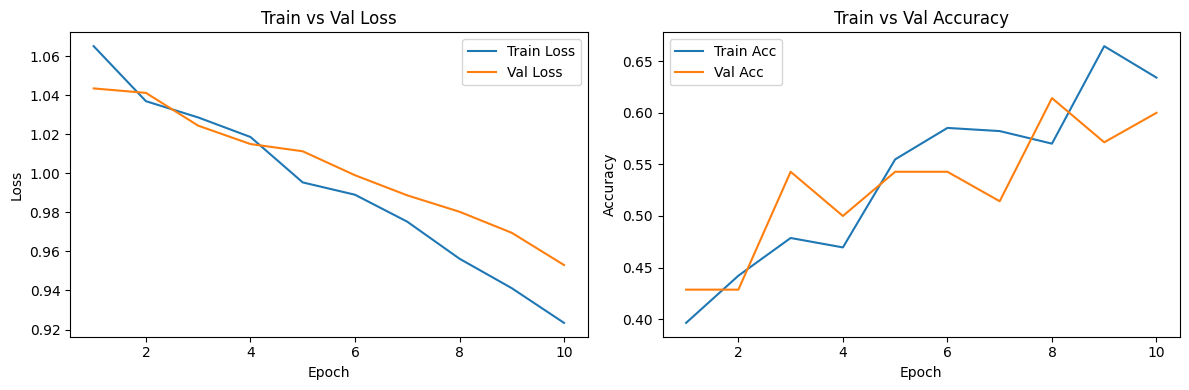

In [23]:
# Plot Loss & Accuracy per epoch

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Eksperimen untuk peningkatan performa

## Helper Model Baru untuk Eksperimen

In [24]:
# Helper: buat model baru dengan config tertentu

def create_model(
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=None,
    dropout=0.1,
    num_classes=None,
    vocab_size=None,
    pad_idx=0,
    max_len=512,
):
    if num_classes is None:
        num_classes = len(label2id)
    if vocab_size is None:
        vocab_size = len(vocab)
    if ff_dim is None:
        ff_dim = embed_dim * 2  # default: 2x embed_dim

    model = TransformerClassifier(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        ff_dim=ff_dim,
        num_classes=num_classes,
        dropout=dropout,
        pad_idx=pad_idx,
        max_len=max_len,
    ).to(DEVICE)
    return model


In [25]:
# Helper: jalankan satu eksperimen training

import time

def run_experiment(
    config_name,
    num_epochs,
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=None,
    dropout=0.1,
    lr=1e-4,
    train_loader=train_loader,
    val_loader=val_loader,
):
    print(f"\n=== Running experiment: {config_name} ===")
    print(f"embed_dim={embed_dim}, heads={num_heads}, layers={num_layers}, "
          f"ff_dim={ff_dim if ff_dim is not None else embed_dim*2}, dropout={dropout}, epochs={num_epochs}")

    model = create_model(
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        ff_dim=ff_dim,
        dropout=dropout,
        pad_idx=pad_idx,
        max_len=max_len,
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []  # simpan metrik per epoch
    start_time_total = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        start_epoch = time.time()

        for batch in train_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        avg_train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)

        val_metrics = evaluate_full(model, val_loader, criterion, DEVICE)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["acc"]
        val_prec = val_metrics["precision"]
        val_rec  = val_metrics["recall"]
        val_f1   = val_metrics["f1"]

        epoch_time = time.time() - start_epoch

        history.append({
            "config":   config_name,
            "epoch":    epoch,
            "train_loss": avg_train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc,
            "val_prec":   val_prec,
            "val_rec":    val_rec,
            "val_f1":     val_f1,
            "epoch_time_sec": epoch_time,
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val P: {val_prec:.4f} | Val R: {val_rec:.4f} | Val F1: {val_f1:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

    total_time = time.time() - start_time_total
    print(f"\nTotal training time for {config_name}: {total_time:.1f} seconds")

    history_df = pd.DataFrame(history)
    return model, history_df


## Eksperimen hingga 50 epochs

In [26]:
# Eksperimen 1: baseline config, epochs = 50

baseline50_model, baseline50_history = run_experiment(
    config_name="baseline_embed128_heads4_layers2_dropout0.1_ep50",
    num_epochs=50,
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    dropout=0.1,
    lr=1e-4,
)


=== Running experiment: baseline_embed128_heads4_layers2_dropout0.1_ep50 ===
embed_dim=128, heads=4, layers=2, ff_dim=256, dropout=0.1, epochs=50


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Train Loss: 1.0639 | Val Loss: 1.0383 | Train Acc: 0.4451 | Val Acc: 0.4857 | Val P: 0.3496 | Val R: 0.3864 | Val F1: 0.3242 | Time: 0.7s
Epoch 02 | Train Loss: 1.0349 | Val Loss: 1.0265 | Train Acc: 0.4329 | Val Acc: 0.5429 | Val P: 0.3620 | Val R: 0.4444 | Val F1: 0.3990 | Time: 0.8s
Epoch 03 | Train Loss: 1.0182 | Val Loss: 1.0245 | Train Acc: 0.5030 | Val Acc: 0.4286 | Val P: 0.1429 | Val R: 0.3333 | Val F1: 0.2000 | Time: 0.8s
Epoch 04 | Train Loss: 1.0242 | Val Loss: 1.0132 | Train Acc: 0.4970 | Val Acc: 0.5286 | Val P: 0.4109 | Val R: 0.4222 | Val F1: 0.3660 | Time: 0.8s
Epoch 05 | Train Loss: 0.9978 | Val Loss: 1.0034 | Train Acc: 0.5823 | Val Acc: 0.5714 | Val P: 0.3806 | Val R: 0.4654 | Val F1: 0.4179 | Time: 1.0s
Epoch 06 | Train Loss: 0.9913 | Val Loss: 0.9943 | Train Acc: 0.6006 | Val Acc: 0.5714 | Val P: 0.3947 | Val R: 0.4630 | Val F1: 0.4165 | Time: 0.9s
Epoch 07 | Train Loss: 0.9802 | Val Loss: 0.9842 | Train Acc: 0.6098 | Val Acc: 0.5857 | Val P: 0.3929 | V

In [27]:
baseline50_history

,config,epoch,train_loss,train_acc,val_loss,val_acc,val_prec,val_rec,val_f1,epoch_time_sec
0,baseline_embed128_heads4_layers2_dropout0.1_ep50,1,1.063855,0.445122,1.038347,0.485714,0.349617,0.386420,0.324204,0.736555
1,baseline_embed128_heads4_layers2_dropout0.1_ep50,2,1.034913,0.432927,1.026495,0.542857,0.361998,0.444444,0.399005,0.772255
2,baseline_embed128_heads4_layers2_dropout0.1_ep50,3,1.018241,0.503049,1.024540,0.428571,0.142857,0.333333,0.200000,0.768196
3,baseline_embed128_heads4_layers2_dropout0.1_ep50,4,1.024223,0.496951,1.013229,0.528571,0.410920,0.422222,0.365967,0.849757
4,baseline_embed128_heads4_layers2_dropout0.1_ep50,5,0.997847,0.582317,1.003426,0.571429,0.380556,0.465432,0.417878,0.972005
5,baseline_embed128_heads4_layers2_dropout0.1_ep50,6,0.991319,0.600610,0.994324,0.571429,0.394696,0.462963,0.416450,0.884419
6,baseline_embed128_heads4_layers2_dropout0.1_ep50,7,0.980163,0.609756,0.984158,0.585714,0.392857,0.476543,0.428283,0.788073
7,baseline_embed128_heads4_layers2_dropout0.1_ep50,8,0.960013,0.640244,0.975304,0.571429,0.399093,0.461728,0.413854,0.753770
8,baseline_embed128_heads4_layers2_dropout0.1_ep50,9,0.943375,0.637195,0.955484,0.585714,0.392857,0.476543,0.428283,0.774226
9,baseline_embed128_heads4_layers2_dropout0.1_ep50,10,0.924270,0.676829,0.940556,0.585714,0.403382,0.475309,0.428449,0.761503


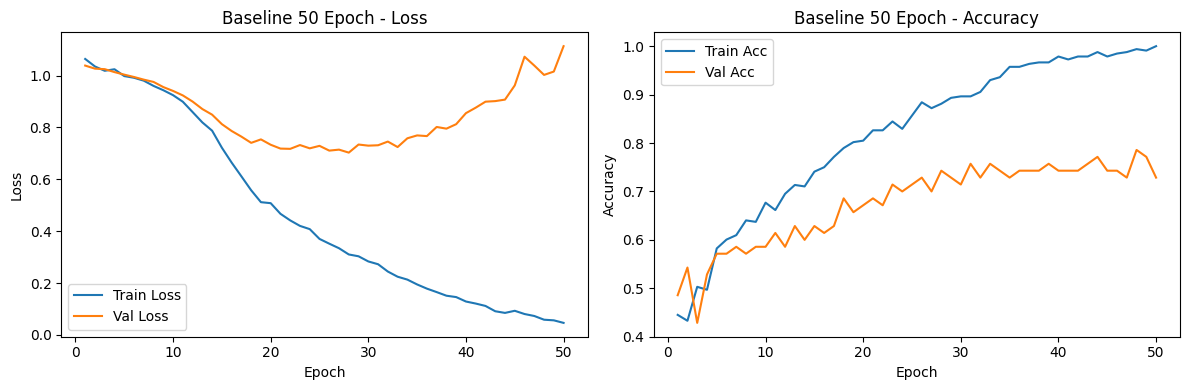

In [28]:
# Plot dari history eksperimen baseline 50 epoch

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(baseline50_history["epoch"], baseline50_history["train_loss"], label="Train Loss")
plt.plot(baseline50_history["epoch"], baseline50_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline 50 Epoch - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(baseline50_history["epoch"], baseline50_history["train_acc"], label="Train Acc")
plt.plot(baseline50_history["epoch"], baseline50_history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline 50 Epoch - Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Eksplor Hyperparameter 50 Epoch

In [29]:
# Daftar konfigurasi hyperparameter untuk diuji

experiment_configs = [
    # --- Ubah embed_dim ---
    {"name": "embed64_h4_l2_do0.1",   "embed_dim": 64,  "num_heads": 4, "num_layers": 2, "dropout": 0.1},
    {"name": "embed256_h4_l2_do0.1",  "embed_dim": 256, "num_heads": 4, "num_layers": 2, "dropout": 0.1},

    # --- Ubah jumlah head ---
    {"name": "embed128_h2_l2_do0.1",  "embed_dim": 128, "num_heads": 2, "num_layers": 2, "dropout": 0.1},
    {"name": "embed128_h8_l2_do0.1",  "embed_dim": 128, "num_heads": 8, "num_layers": 2, "dropout": 0.1},

    # --- Ubah jumlah layer encoder ---
    {"name": "embed128_h4_l1_do0.1",  "embed_dim": 128, "num_heads": 4, "num_layers": 1, "dropout": 0.1},
    {"name": "embed128_h4_l4_do0.1",  "embed_dim": 128, "num_heads": 4, "num_layers": 4, "dropout": 0.1},

    # --- Ubah dropout ---
    {"name": "embed128_h4_l2_do0.3",  "embed_dim": 128, "num_heads": 4, "num_layers": 2, "dropout": 0.3},
    {"name": "embed128_h4_l2_do0.5",  "embed_dim": 128, "num_heads": 4, "num_layers": 2, "dropout": 0.5},
]


In [30]:
all_histories = []

for cfg in experiment_configs:
    _, hist = run_experiment(
        config_name=cfg["name"],
        num_epochs=50,
        embed_dim=cfg["embed_dim"],
        num_heads=cfg["num_heads"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        lr=1e-4,
    )
    all_histories.append(hist)

# Gabungkan semua hasil jadi satu DataFrame
all_history_df = pd.concat(all_histories, ignore_index=True)



=== Running experiment: embed64_h4_l2_do0.1 ===
embed_dim=64, heads=4, layers=2, ff_dim=128, dropout=0.1, epochs=50


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Train Loss: 1.0751 | Val Loss: 1.0564 | Train Acc: 0.4177 | Val Acc: 0.4000 | Val P: 0.2465 | Val R: 0.3136 | Val F1: 0.2248 | Time: 0.5s
Epoch 02 | Train Loss: 1.0439 | Val Loss: 1.0441 | Train Acc: 0.4329 | Val Acc: 0.4143 | Val P: 0.1401 | Val R: 0.3222 | Val F1: 0.1953 | Time: 0.6s
Epoch 03 | Train Loss: 1.0398 | Val Loss: 1.0405 | Train Acc: 0.4421 | Val Acc: 0.4000 | Val P: 0.1373 | Val R: 0.3111 | Val F1: 0.1905 | Time: 0.6s
Epoch 04 | Train Loss: 1.0318 | Val Loss: 1.0368 | Train Acc: 0.4909 | Val Acc: 0.4000 | Val P: 0.2465 | Val R: 0.3136 | Val F1: 0.2248 | Time: 0.6s
Epoch 05 | Train Loss: 1.0321 | Val Loss: 1.0331 | Train Acc: 0.5030 | Val Acc: 0.5143 | Val P: 0.3700 | Val R: 0.4160 | Val F1: 0.3761 | Time: 0.6s
Epoch 06 | Train Loss: 1.0338 | Val Loss: 1.0297 | Train Acc: 0.5061 | Val Acc: 0.5143 | Val P: 0.4052 | Val R: 0.4111 | Val F1: 0.3584 | Time: 0.5s
Epoch 07 | Train Loss: 1.0265 | Val Loss: 1.0261 | Train Acc: 0.5000 | Val Acc: 0.5429 | Val P: 0.4226 | V

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Train Loss: 1.0649 | Val Loss: 1.0210 | Train Acc: 0.4238 | Val Acc: 0.4143 | Val P: 0.2532 | Val R: 0.3259 | Val F1: 0.2460 | Time: 1.2s
Epoch 02 | Train Loss: 1.0419 | Val Loss: 1.0076 | Train Acc: 0.4329 | Val Acc: 0.5571 | Val P: 0.3715 | Val R: 0.4580 | Val F1: 0.4096 | Time: 1.3s
Epoch 03 | Train Loss: 1.0144 | Val Loss: 1.0145 | Train Acc: 0.5640 | Val Acc: 0.5571 | Val P: 0.4444 | Val R: 0.4457 | Val F1: 0.3906 | Time: 1.3s
Epoch 04 | Train Loss: 0.9815 | Val Loss: 0.9845 | Train Acc: 0.6189 | Val Acc: 0.5857 | Val P: 0.4202 | Val R: 0.4716 | Val F1: 0.4202 | Time: 1.3s
Epoch 05 | Train Loss: 0.9638 | Val Loss: 0.9709 | Train Acc: 0.5488 | Val Acc: 0.6429 | Val P: 0.4331 | Val R: 0.5309 | Val F1: 0.4711 | Time: 1.3s
Epoch 06 | Train Loss: 0.9258 | Val Loss: 0.9565 | Train Acc: 0.6494 | Val Acc: 0.5714 | Val P: 0.3807 | Val R: 0.4679 | Val F1: 0.4198 | Time: 1.3s
Epoch 07 | Train Loss: 0.8644 | Val Loss: 0.9669 | Train Acc: 0.6921 | Val Acc: 0.5143 | Val P: 0.3409 | V

...

Epoch 01 | Train Loss: 1.0900 | Val Loss: 1.0672 | Train Acc: 0.4146 | Val Acc: 0.4000 | Val P: 0.4638 | Val R: 0.3444 | Val F1: 0.2090 | Time: 1.3s
Epoch 02 | Train Loss: 1.0314 | Val Loss: 1.0419 | Train Acc: 0.4573 | Val Acc: 0.4143 | Val P: 0.1422 | Val R: 0.3222 | Val F1: 0.1973 | Time: 1.3s
Epoch 03 | Train Loss: 1.0373 | Val Loss: 1.0252 | Train Acc: 0.4665 | Val Acc: 0.4714 | Val P: 0.3300 | Val R: 0.3938 | Val F1: 0.3371 | Time: 1.3s
Epoch 04 | Train Loss: 1.0206 | Val Loss: 1.0137 | Train Acc: 0.5000 | Val Acc: 0.5143 | Val P: 0.3430 | Val R: 0.4198 | Val F1: 0.3771 | Time: 1.3s
Epoch 05 | Train Loss: 1.0053 | Val Loss: 1.0033 | Train Acc: 0.5335 | Val Acc: 0.5571 | Val P: 0.3730 | Val R: 0.4531 | Val F1: 0.4069 | Time: 1.3s
Epoch 06 | Train Loss: 0.9864 | Val Loss: 0.9915 | Train Acc: 0.5671 | Val Acc: 0.5143 | Val P: 0.3514 | Val R: 0.4259 | Val F1: 0.3758 | Time: 1.3s
Epoch 07 | Train Loss: 0.9615 | Val Loss: 0.9723 | Train Acc: 0.5884 | Val Acc: 0.5714 | Val P: 0.4045 | V

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Train Loss: 1.0820 | Val Loss: 1.0333 | Train Acc: 0.3689 | Val Acc: 0.4286 | Val P: 0.1429 | Val R: 0.3333 | Val F1: 0.2000 | Time: 0.7s
Epoch 02 | Train Loss: 1.0499 | Val Loss: 1.0223 | Train Acc: 0.4512 | Val Acc: 0.4286 | Val P: 0.1429 | Val R: 0.3333 | Val F1: 0.2000 | Time: 0.7s
Epoch 03 | Train Loss: 1.0354 | Val Loss: 1.0154 | Train Acc: 0.4573 | Val Acc: 0.5857 | Val P: 0.3968 | Val R: 0.4840 | Val F1: 0.4291 | Time: 0.7s
Epoch 04 | Train Loss: 1.0073 | Val Loss: 1.0087 | Train Acc: 0.5000 | Val Acc: 0.5286 | Val P: 0.3739 | Val R: 0.4259 | Val F1: 0.3797 | Time: 0.7s
Epoch 05 | Train Loss: 1.0066 | Val Loss: 0.9995 | Train Acc: 0.4817 | Val Acc: 0.5857 | Val P: 0.3912 | Val R: 0.4815 | Val F1: 0.4304 | Time: 0.7s
Epoch 06 | Train Loss: 1.0094 | Val Loss: 0.9911 | Train Acc: 0.5000 | Val Acc: 0.5143 | Val P: 0.4476 | Val R: 0.4086 | Val F1: 0.3435 | Time: 0.7s
Epoch 07 | Train Loss: 0.9927 | Val Loss: 0.9782 | Train Acc: 0.5152 | Val Acc: 0.5571 | Val P: 0.4286 | V

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 | Train Loss: 1.1040 | Val Loss: 1.0446 | Train Acc: 0.3415 | Val Acc: 0.4143 | Val P: 0.1401 | Val R: 0.3222 | Val F1: 0.1953 | Time: 0.7s
Epoch 02 | Train Loss: 1.0491 | Val Loss: 1.0427 | Train Acc: 0.4329 | Val Acc: 0.4571 | Val P: 0.3054 | Val R: 0.3704 | Val F1: 0.3311 | Time: 0.7s
Epoch 03 | Train Loss: 1.0503 | Val Loss: 1.0425 | Train Acc: 0.4146 | Val Acc: 0.5000 | Val P: 0.3370 | Val R: 0.4037 | Val F1: 0.3591 | Time: 0.7s
Epoch 04 | Train Loss: 1.0458 | Val Loss: 1.0326 | Train Acc: 0.4482 | Val Acc: 0.5143 | Val P: 0.3537 | Val R: 0.4148 | Val F1: 0.3692 | Time: 0.7s
Epoch 05 | Train Loss: 1.0327 | Val Loss: 1.0263 | Train Acc: 0.4787 | Val Acc: 0.5000 | Val P: 0.3512 | Val R: 0.3988 | Val F1: 0.3394 | Time: 0.7s
Epoch 06 | Train Loss: 1.0064 | Val Loss: 1.0231 | Train Acc: 0.5091 | Val Acc: 0.5286 | Val P: 0.3636 | Val R: 0.4272 | Val F1: 0.3820 | Time: 0.7s
Epoch 07 | Train Loss: 1.0159 | Val Loss: 1.0190 | Train Acc: 0.5427 | Val Acc: 0.5429 | Val P: 0.3644 | V

In [31]:
# Ringkasan: ambil epoch dengan val_f1 tertinggi per config

summary = (
    all_history_df
    .sort_values(["config", "val_f1"], ascending=[True, False])
    .groupby("config")
    .head(1)[["config", "epoch", "val_loss", "val_acc", "val_f1", "epoch_time_sec"]]
    .reset_index(drop=True)
)

summary


,config,epoch,val_loss,val_acc,val_f1,epoch_time_sec
0,embed128_h2_l2_do0.1,27,0.831118,0.700000,0.652859,0.598156
1,embed128_h4_l1_do0.1,48,0.822631,0.671429,0.620202,0.445652
2,embed128_h4_l2_do0.3,37,0.643035,0.800000,0.730293,0.688490
3,embed128_h4_l2_do0.5,49,0.995364,0.742857,0.678162,0.688823
4,embed128_h4_l4_do0.1,36,0.920954,0.728571,0.680400,1.348807
5,embed128_h8_l2_do0.1,49,0.868675,0.771429,0.732213,0.980740
6,embed256_h4_l2_do0.1,29,0.956060,0.785714,0.764751,1.294058
7,embed64_h4_l2_do0.1,50,0.742375,0.785714,0.724242,0.576786


# Helper plot per config

In [32]:
import matplotlib.pyplot as plt

def plot_configs(history_df, configs, metric="val_f1", title=""):
    plt.figure(figsize=(6,4))
    for cfg in configs:
        sub = history_df[history_df["config"] == cfg]
        if len(sub) == 0:
            continue
        plt.plot(sub["epoch"], sub[metric], marker="o", label=cfg)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


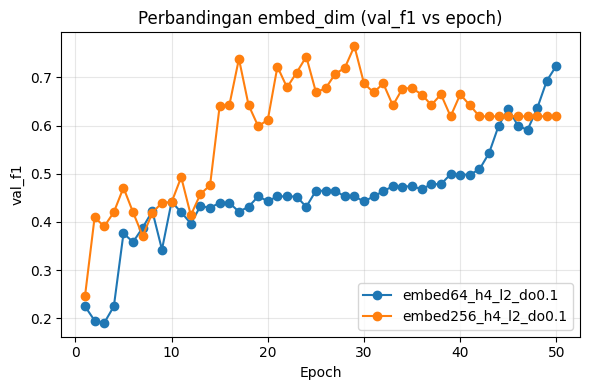

In [33]:
embed_configs = [
    "embed64_h4_l2_do0.1",
    "embed256_h4_l2_do0.1",
    # kalau kamu punya history untuk baseline embed128_h4_l2_do0.1,
    # bisa ditambah di sini juga.
]

plot_configs(
    all_history_df,
    embed_configs,
    metric="val_f1",
    title="Perbandingan embed_dim (val_f1 vs epoch)"
)


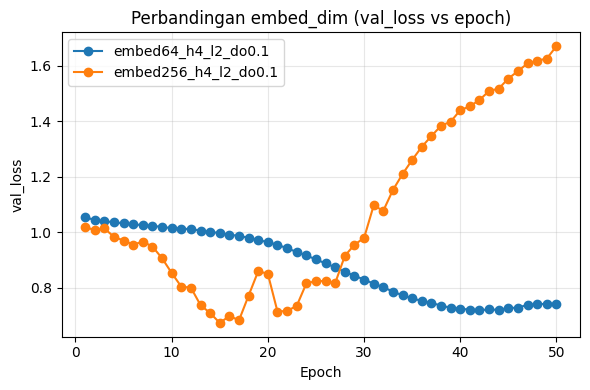

In [34]:
plot_configs(
    all_history_df,
    embed_configs,
    metric="val_loss",
    title="Perbandingan embed_dim (val_loss vs epoch)"
)


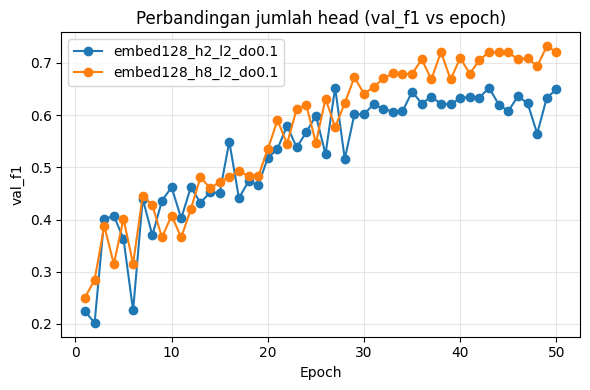

In [35]:
heads_configs = [
    "embed128_h2_l2_do0.1",
    "embed128_h8_l2_do0.1",
    # tambah "embed128_h4_l2_do0.1" kalau kamu punya history-nya
]

plot_configs(
    all_history_df,
    heads_configs,
    metric="val_f1",
    title="Perbandingan jumlah head (val_f1 vs epoch)"
)


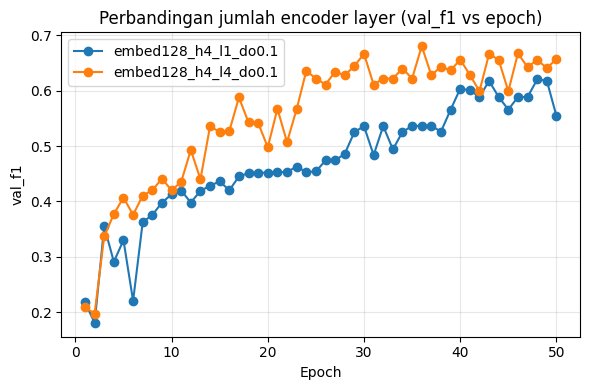

In [36]:
layers_configs = [
    "embed128_h4_l1_do0.1",
    "embed128_h4_l4_do0.1",
    # kalau ada "embed128_h4_l2_do0.1", kamu bisa masukin di sini juga
]

plot_configs(
    all_history_df,
    layers_configs,
    metric="val_f1",
    title="Perbandingan jumlah encoder layer (val_f1 vs epoch)"
)


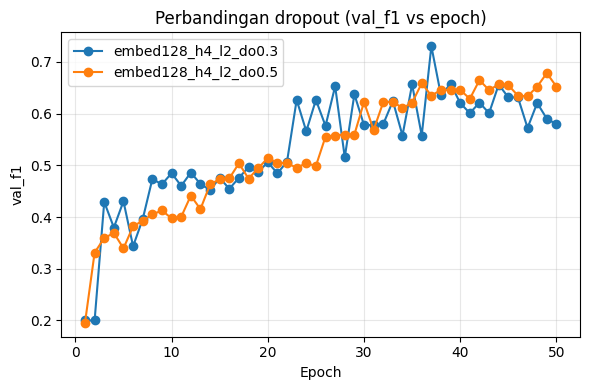

In [37]:
dropout_configs = [
    # "embed128_h4_l2_do0.1",  # tambahkan kalau history-nya ada
    "embed128_h4_l2_do0.3",
    "embed128_h4_l2_do0.5",
]

plot_configs(
    all_history_df,
    dropout_configs,
    metric="val_f1",
    title="Perbandingan dropout (val_f1 vs epoch)"
)


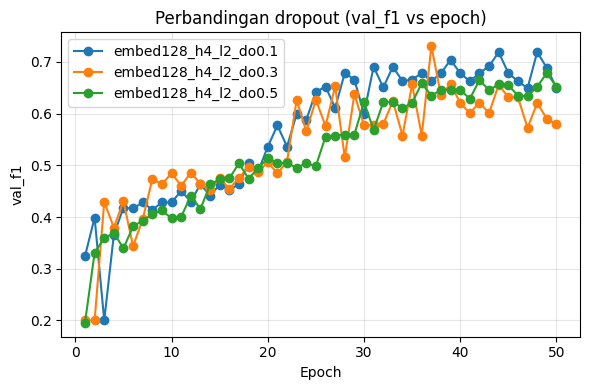

In [38]:
baseline50_history["config"] = "embed128_h4_l2_do0.1"
all_history_with_base = pd.concat([all_history_df, baseline50_history], ignore_index=True)

dropout_configs = [
    "embed128_h4_l2_do0.1",
    "embed128_h4_l2_do0.3",
    "embed128_h4_l2_do0.5",
]

plot_configs(
    all_history_with_base,
    dropout_configs,
    metric="val_f1",
    title="Perbandingan dropout (val_f1 vs epoch)"
)


# Zero Shot Learning

In [39]:
!pip install transformers --quiet

In [40]:
from transformers import pipeline

zero_xlmr = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli"
)

zero_bart = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

labels = ["positive", "neutral", "negative"]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [41]:
candidate_labels = ["Negative", "Neutral", "Positive"]

# Mapping output zero-shot (lowercase) → label dataset (Capitalized)
zs_to_dataset_label = {
    "negative": "Negative",
    "neutral": "Neutral",
    "positive": "Positive",
}

def evaluate_zero_shot(model_pipeline, texts, labels, label2id):
    preds = []

    for t in texts:
        output = model_pipeline(t, candidate_labels)

        # HF pipeline mengembalikan lowercase label
        zs_label = output["labels"][np.argmax(output["scores"])].lower()

        # map ke label dataset (Capitalized)
        mapped_dataset_label = zs_to_dataset_label[zs_label]

        pred_id = label2id[mapped_dataset_label]
        preds.append(pred_id)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    return {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [42]:
print("=== Zero-Shot XLM-RoBERTa ===")
zs_xlmr_metrics = evaluate_zero_shot(
    zero_xlmr,
    test_texts,
    test_labels,
    label2id
)
print(zs_xlmr_metrics)

print("\n=== Zero-Shot BART-Large ===")
zs_bart_metrics = evaluate_zero_shot(
    zero_bart,
    test_texts,
    test_labels,
    label2id
)
print(zs_bart_metrics)


=== Zero-Shot XLM-RoBERTa ===


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


{'acc': 0.4647887323943662, 'precision': 0.4100985221674877, 'recall': 0.4084249084249085, 'f1': 0.40893101207680765}

=== Zero-Shot BART-Large ===
{'acc': 0.49295774647887325, 'precision': 0.45242656449553004, 'recall': 0.4314407814407814, 'f1': 0.428049732381802}


In [43]:
zero_df = pd.DataFrame([
    {"model": "XLM-R Large XNLI", **zs_xlmr_metrics},
    {"model": "BART Large MNLI", **zs_bart_metrics},
])

print("\n=== Zero-Shot Summary ===")
display(zero_df)


=== Zero-Shot Summary ===


,model,acc,precision,recall,f1
0,XLM-R Large XNLI,0.464789,0.410099,0.408425,0.408931
1,BART Large MNLI,0.492958,0.452427,0.431441,0.428050


# Perbandingan Cleaned Text Epoch 50

In [50]:
# 50 Epoch - TRANSFORMER on CLEANED TEXT

TEXT_COL = CLEAN_TEXT_COL  # ganti ke kolom teks yang clean

# 1. Split data khusus teks clean
splits_clean = get_splits(TEXT_COL)

train_texts_clean = splits_clean["train_texts"]
val_texts_clean   = splits_clean["val_texts"]
test_texts_clean  = splits_clean["test_texts"]

train_labels_clean = splits_clean["train_labels"]
val_labels_clean   = splits_clean["val_labels"]
test_labels_clean  = splits_clean["test_labels"]

print("Train clean:", len(train_texts_clean))
print("Val clean  :", len(val_texts_clean))
print("Test clean :", len(test_texts_clean))

Train clean: 328
Val clean  : 70
Test clean : 71


In [52]:
def build_vocab_and_max_len(texts, min_freq=2, max_percentile=95):
    # hitung frekuensi token
    token_freq = Counter()
    lengths = []

    for t in texts:
        tokens = tokenize(t)
        lengths.append(len(tokens))
        for tok in tokens:
            token_freq[tok] += 1

    # tentukan max_len dari percentile
    max_len = int(np.percentile(lengths, max_percentile))

    # buat vocab (dengan PAD dan UNK)
    vocab = {"[PAD]": 0, "[UNK]": 1}
    for tok, freq in token_freq.items():
        if freq >= min_freq:
            vocab[tok] = len(vocab)

    return vocab, max_len

In [53]:
# 2. Build vocab + max_len khusus clean
vocab_clean, max_len_clean = build_vocab_and_max_len(train_texts_clean)

pad_idx_clean = vocab_clean["[PAD]"]

In [55]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len, pad_idx=0):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = pad_idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids, attn_mask = encode_text(
            text,
            self.vocab,
            self.max_len,
            pad_idx=self.pad_idx
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn_mask, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }


In [56]:
# 3. Dataset + DataLoader untuk teks clean
train_dataset_clean = TextDataset(
    train_texts_clean,
    train_labels_clean,
    vocab_clean,
    max_len_clean,
    pad_idx=pad_idx_clean,
)

val_dataset_clean = TextDataset(
    val_texts_clean,
    val_labels_clean,
    vocab_clean,
    max_len_clean,
    pad_idx=pad_idx_clean,
)

test_dataset_clean = TextDataset(
    test_texts_clean,
    test_labels_clean,
    vocab_clean,
    max_len_clean,
    pad_idx=pad_idx_clean,
)

BATCH_SIZE = 32

train_loader_clean = DataLoader(train_dataset_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader_clean   = DataLoader(val_dataset_clean,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_clean  = DataLoader(test_dataset_clean,  batch_size=BATCH_SIZE, shuffle=False)

In [57]:
# 4. Inisialisasi model baru
model_clean = TransformerClassifier(
    vocab_size=len(vocab_clean),
    embed_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=256,
    dropout=0.1,
    num_classes=3,
    pad_idx=pad_idx_clean,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_clean.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [58]:
# 5. Training 50 epoch untuk teks CLEANED
NUM_EPOCHS = 50

train_losses_clean = []
val_losses_clean   = []
train_accs_clean   = []
val_accs_clean     = []

for epoch in range(1, NUM_EPOCHS + 1):
    model_clean.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in train_loader_clean:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model_clean(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader_clean.dataset)
    train_acc = accuracy_score(all_labels, all_preds)

    val_metrics = evaluate_full(model_clean, val_loader_clean, criterion, DEVICE)

    train_losses_clean.append(avg_train_loss)
    val_losses_clean.append(val_metrics["loss"])
    train_accs_clean.append(train_acc)
    val_accs_clean.append(val_metrics["acc"])

    print(
        f"[CLEAN] Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['acc']:.4f} | "
        f"Val P: {val_metrics['precision']:.4f} | Val R: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

print("=== Selesai training 50 epoch untuk CLEANED TEXT ===")

[CLEAN] Epoch 01 | Train Loss: 1.0876 | Val Loss: 1.0370 | Train Acc: 0.3537 | Val Acc: 0.4000 | Val P: 0.2051 | Val R: 0.3123 | Val F1: 0.2103
[CLEAN] Epoch 02 | Train Loss: 1.0343 | Val Loss: 1.0302 | Train Acc: 0.4482 | Val Acc: 0.4571 | Val P: 0.3056 | Val R: 0.3778 | Val F1: 0.3347
[CLEAN] Epoch 03 | Train Loss: 1.0190 | Val Loss: 1.0191 | Train Acc: 0.5122 | Val Acc: 0.5857 | Val P: 0.3959 | Val R: 0.4765 | Val F1: 0.4291
[CLEAN] Epoch 04 | Train Loss: 1.0062 | Val Loss: 1.0089 | Train Acc: 0.5549 | Val Acc: 0.5429 | Val P: 0.4202 | Val R: 0.4346 | Val F1: 0.3812
[CLEAN] Epoch 05 | Train Loss: 0.9941 | Val Loss: 0.9992 | Train Acc: 0.5640 | Val Acc: 0.5714 | Val P: 0.4138 | Val R: 0.4605 | Val F1: 0.4121
[CLEAN] Epoch 06 | Train Loss: 0.9730 | Val Loss: 0.9876 | Train Acc: 0.6402 | Val Acc: 0.6286 | Val P: 0.4444 | Val R: 0.5086 | Val F1: 0.4585
[CLEAN] Epoch 07 | Train Loss: 0.9659 | Val Loss: 0.9750 | Train Acc: 0.6463 | Val Acc: 0.6571 | Val P: 0.4380 | Val R: 0.5370 | Val F1:

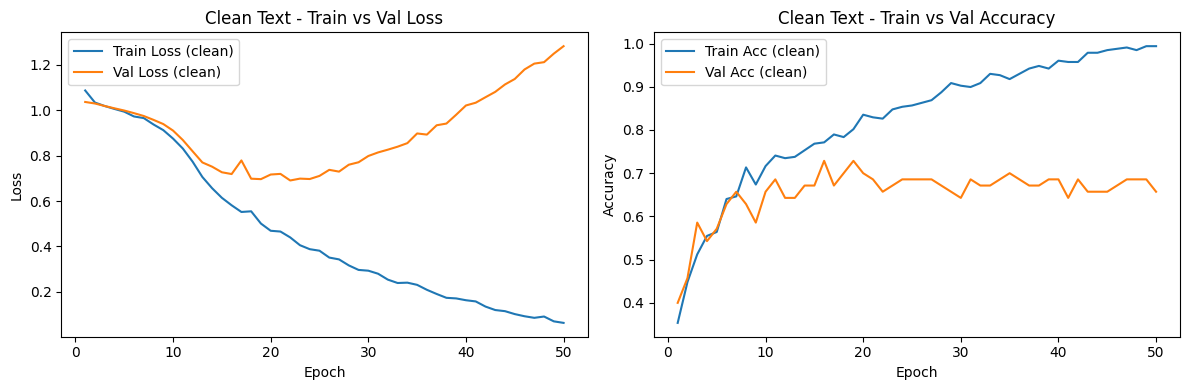

In [59]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses_clean, label="Train Loss (clean)")
plt.plot(epochs, val_losses_clean,   label="Val Loss (clean)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Clean Text - Train vs Val Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accs_clean, label="Train Acc (clean)")
plt.plot(epochs, val_accs_clean,   label="Val Acc (clean)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Clean Text - Train vs Val Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
